# Cross-Asset Diversified Vol-Targeted Portfolio

Notebook 05 showed that 8 US equity ETFs share a 0.71 correlation — too high to deliver real diversification. This notebook tests the natural fix: replace the equity-only universe with a truly cross-asset basket of equity, bonds, gold, and commodities, where correlations should be much lower.

**Universe:**
- **SPY** — US equities
- **TLT** — long-duration US Treasuries (20+ year)
- **GLD** — gold
- **DBC** — broad commodities (energy, agriculture, metals)

**Strategy:** vol-target each asset to 15% annualized, equal-weight combine.

**Hypothesis:** the 4-asset cross-asset portfolio should achieve a higher diversification ratio than the 8-asset equity portfolio from notebook 05 — and a better Sharpe for the same realized vol.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TRADING_DAYS = 252
START = '2010-01-01'
END = '2026-05-08'
TICKERS = ['SPY', 'TLT', 'GLD', 'DBC']
TARGET_VOL = 0.15
VOL_LOOKBACK = 20
MAX_LEVERAGE = 2.0
COST_BPS = 5

## 1. Data

In [2]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'] if 'Close' in raw.columns.get_level_values(0) else raw
prices = prices[TICKERS].dropna()
rets = prices.pct_change().fillna(0)
print(f'Rows: {len(prices)}  Range: {prices.index.min().date()} to {prices.index.max().date()}')
rets.head()

Rows: 4111  Range: 2010-01-04 to 2026-05-07


Ticker,SPY,TLT,GLD,DBC
Date,,,,
2010-01-04,0.000000,0.000000,0.000000,0.000000
2010-01-05,0.002647,0.006458,-0.000911,0.001189
2010-01-06,0.000704,-0.013386,0.016500,0.017808
2010-01-07,0.004221,0.001681,-0.006188,-0.012442
2010-01-08,0.003328,-0.000448,0.004963,-0.000787


## 2. Correlation matrix

We expect bonds (TLT) to be negatively correlated with equities (SPY) over long stretches, gold (GLD) lightly correlated with both, and commodities (DBC) weakly correlated with equities and modestly with gold.

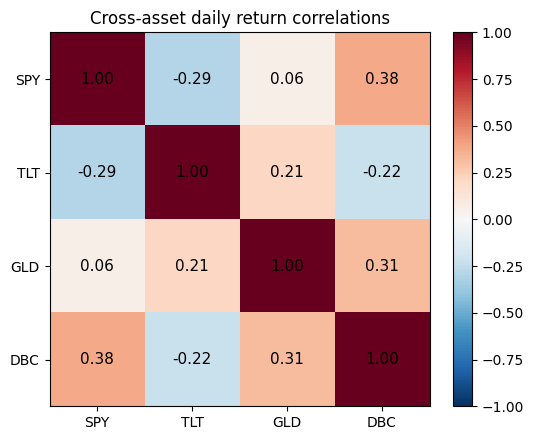

Mean off-diagonal correlation: 0.075


In [3]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS)
ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', color='black', fontsize=11)
ax.set_title('Cross-asset daily return correlations')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
n = len(TICKERS)
mean_corr = (corr.values.sum() - n) / (n * (n - 1))
print(f'Mean off-diagonal correlation: {mean_corr:.3f}')

## 3. Per-asset vol-targeted positions and combined portfolio

In [4]:
def vol_target_position(returns, target_vol=TARGET_VOL, lookback=VOL_LOOKBACK, max_lev=MAX_LEVERAGE):
    rv = returns.rolling(lookback).std() * np.sqrt(TRADING_DAYS)
    pos = (target_vol / rv).clip(upper=max_lev).fillna(0)
    return pos.shift(1).fillna(0)

positions = pd.DataFrame({t: vol_target_position(rets[t]) for t in TICKERS})
exp_changes = positions.diff().abs().fillna(0)
asset_strat_rets = rets * positions - (COST_BPS / 10000.0) * exp_changes

combo = pd.DataFrame(index=rets.index)
combo['vt_xasset'] = asset_strat_rets.mean(axis=1)
combo['eq_buyhold'] = rets.mean(axis=1)
combo['vt_spy_only'] = rets['SPY'] * vol_target_position(rets['SPY']) - (COST_BPS / 10000.0) * vol_target_position(rets['SPY']).diff().abs().fillna(0)
combo['spy_buyhold'] = rets['SPY']

equity = (1 + combo).cumprod()
equity.tail()

,vt_xasset,eq_buyhold,vt_spy_only,spy_buyhold
Date,,,,
2026-05-01,3.086767,3.398788,8.849722,8.498594
2026-05-04,3.068763,3.386558,8.808870,8.467460
2026-05-05,3.087315,3.401789,8.895017,8.535388
2026-05-06,3.112465,3.418897,9.046309,8.654025
2026-05-07,3.102949,3.414566,9.004254,8.627490


## 4. Performance metrics

In [5]:
def perf(returns, equity):
    years = len(returns) / TRADING_DAYS
    cagr = equity.iloc[-1] ** (1 / years) - 1 if equity.iloc[-1] > 0 else -1
    rv = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() > 0 else 0
    dd = (equity / equity.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd != 0 else np.nan
    return {'cagr': cagr, 'realized_vol': rv, 'sharpe': sharpe, 'max_dd': dd, 'calmar': calmar}

summary = pd.DataFrame({col: perf(combo[col], equity[col]) for col in combo.columns}).T
summary

,cagr,realized_vol,sharpe,max_dd,calmar
vt_xasset,0.071878,0.091436,0.805005,-0.280418,0.256324
eq_buyhold,0.078184,0.092582,0.859563,-0.194294,0.402401
vt_spy_only,0.144212,0.163257,0.907385,-0.199957,0.721218
spy_buyhold,0.141218,0.171447,0.856611,-0.337173,0.418831


## 5. Diversification ratio — does cross-asset deliver?

In [6]:
asset_vols = asset_strat_rets.std() * np.sqrt(TRADING_DAYS)
weighted_avg_vol = asset_vols.mean()
portfolio_vol = combo['vt_xasset'].std() * np.sqrt(TRADING_DAYS)
div_ratio = weighted_avg_vol / portfolio_vol
max_possible = np.sqrt(len(TICKERS))

print(f'Per-asset realized vol:')
for t, v in asset_vols.items():
    print(f'  {t}: {v:.2%}')
print(f'\nMean per-asset vol:        {weighted_avg_vol:.2%}')
print(f'Portfolio vol (vt_xasset): {portfolio_vol:.2%}')
print(f'Diversification ratio:     {div_ratio:.2f}')
print(f'Max possible (sqrt N=4):   {max_possible:.2f}')
print(f'Diversification efficiency: {(div_ratio - 1) / (max_possible - 1):.1%}')
print()
print(f'Compare to notebook 05 (8 US equity ETFs): DR=1.21, efficiency=11.4%')

Per-asset realized vol:
  SPY: 16.33%
  TLT: 15.93%
  GLD: 16.70%
  DBC: 16.52%

Mean per-asset vol:        16.37%
Portfolio vol (vt_xasset): 9.14%
Diversification ratio:     1.79
Max possible (sqrt N=4):   2.00
Diversification efficiency: 79.0%

Compare to notebook 05 (8 US equity ETFs): DR=1.21, efficiency=11.4%


## 6. Equity curves

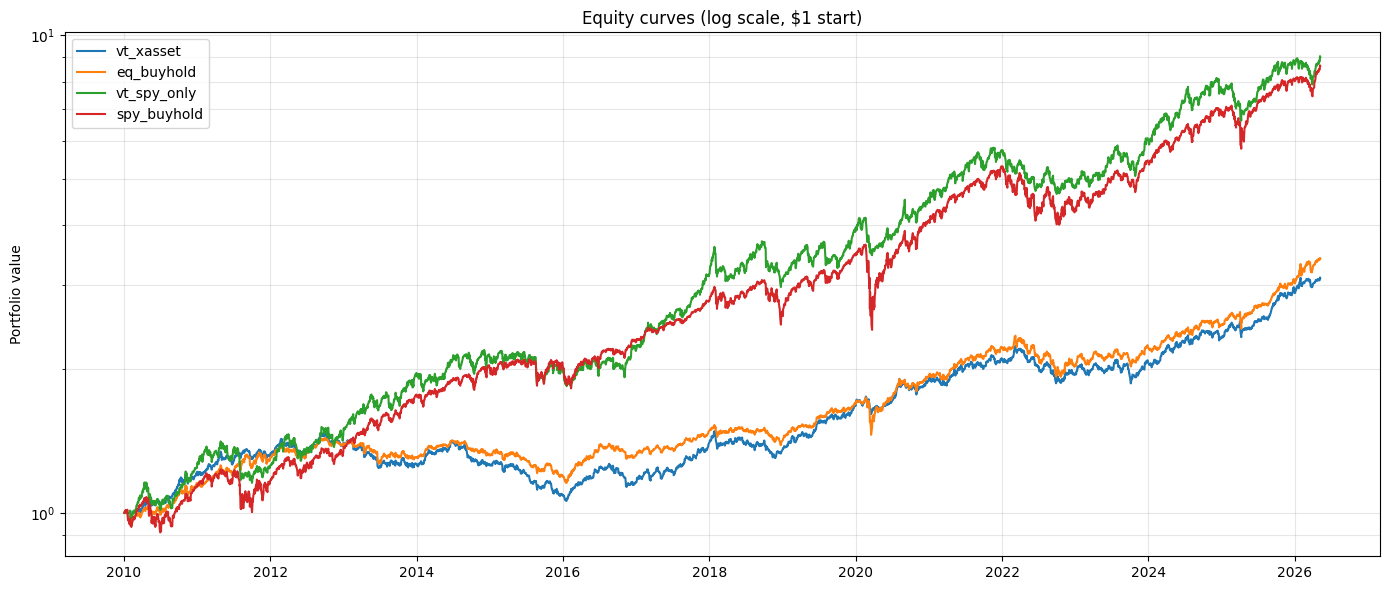

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
for col in equity.columns:
    ax.plot(equity.index, equity[col], label=col, linewidth=1.5)
ax.set_yscale('log')
ax.set_title('Equity curves (log scale, $1 start)')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 7. Drawdowns

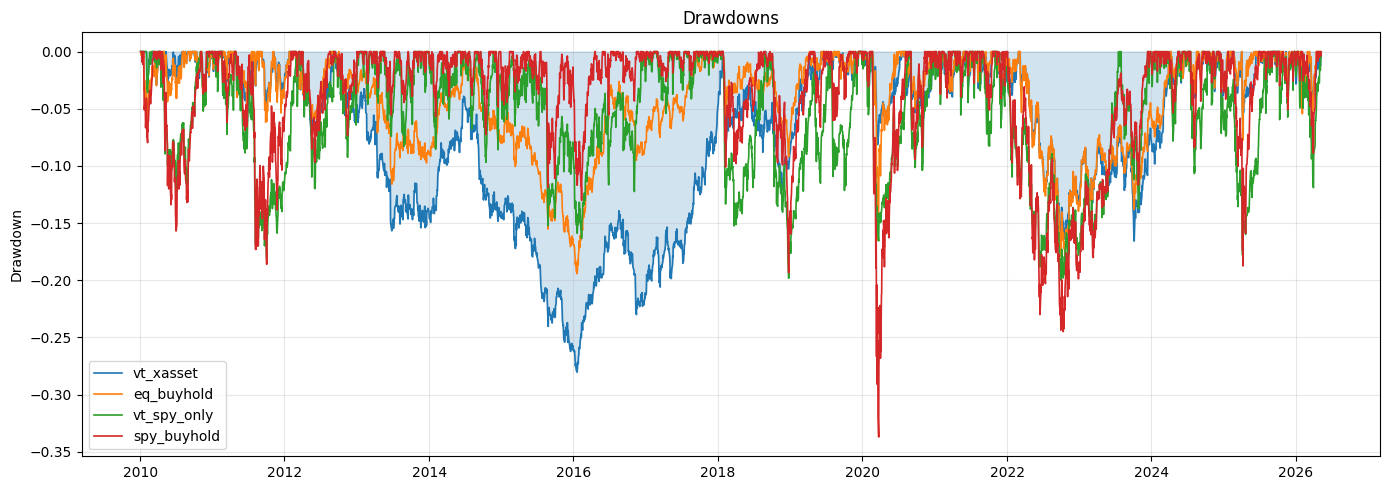

In [8]:
dd = equity / equity.cummax() - 1
fig, ax = plt.subplots(figsize=(14, 5))
for col in dd.columns:
    ax.plot(dd.index, dd[col], label=col, linewidth=1.2)
ax.fill_between(dd.index, dd['vt_xasset'], 0, color='tab:blue', alpha=0.2)
ax.set_title('Drawdowns')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Per-asset contribution to portfolio over time

How much each asset is contributing to the portfolio's daily return. Lets us see whether one asset dominates or whether contributions are reasonably balanced.

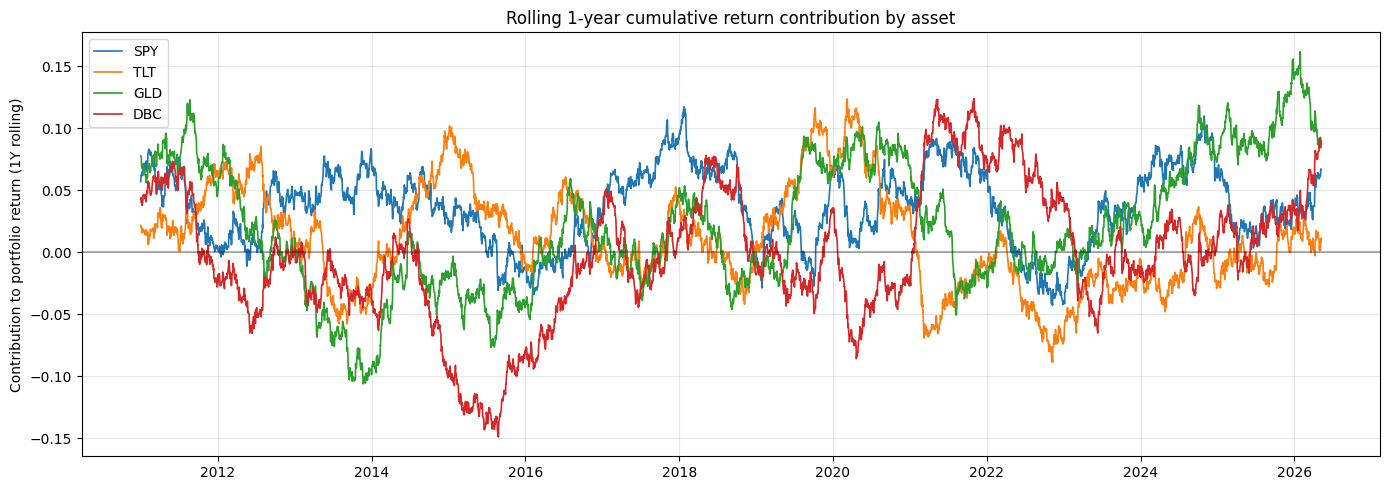

In [9]:
contributions = asset_strat_rets / len(TICKERS)  # equal weight
rolling_contrib = contributions.rolling(252).sum()

fig, ax = plt.subplots(figsize=(14, 5))
for ticker in TICKERS:
    ax.plot(rolling_contrib.index, rolling_contrib[ticker], label=ticker, linewidth=1.2)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_title('Rolling 1-year cumulative return contribution by asset')
ax.set_ylabel('Contribution to portfolio return (1Y rolling)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Honest read

The diversification hypothesis was **confirmed mathematically** but **failed economically**.

**Mathematical win:**

| Metric | Notebook 05 (8 equity ETFs) | Notebook 06 (4 cross-asset) |
|---|---|---|
| Mean off-diagonal correlation | 0.71 | **0.075** |
| Portfolio realized vol | 13.5% | **9.1%** |
| Diversification ratio | 1.21 | **1.79** |
| DR efficiency vs sqrt(N) | 11.4% | **79.0%** |

A 10x reduction in average correlation, and 7x improvement in diversification efficiency. Pure math: the cross-asset basket really does combine 4 risk streams that move much more independently than 8 sector ETFs.

**Economic disappointment:**

| Strategy | CAGR | Sharpe | Max DD | Calmar |
|---|---|---|---|---|
| vt_xasset (4 assets) | 7.2% | 0.81 | -28.0% | 0.26 |
| eq_buyhold (4 assets) | 7.8% | 0.86 | -19.4% | 0.40 |
| vt_spy_only | 14.4% | 0.91 | -20.0% | 0.72 |
| spy_buyhold | 14.1% | 0.86 | -33.7% | 0.42 |

`vt_xasset` has the lowest Sharpe and the **worst** drawdown of any strategy in this notebook. Why?

1. TLT, GLD, and DBC each have lower individual Sharpe than SPY over this 16-year window. Combining them dilutes the average.
2. Vol-targeting leveraged TLT during the long low-vol period of 2010-2021, then took a brutal hit when bonds and stocks crashed together in 2022. Historical SPY/TLT negative correlation flipped positive in the inflation regime.
3. Diversification-of-vol is not the same as diversification-of-return.

## Lesson

Vol math is the easy part. The hard part is that risk targeting and diversification only help when:

- Each asset has a positive Sharpe on its own.
- The correlations that produce diversification on average **stay** that way during the worst stress periods.

Both assumptions failed here. 2022 broke the bond hedge. Commodities and gold rallied during the inflation period, but at lower Sharpe than equities long-term.

The real next step is regime-conditional weighting — recognize that the SPY/TLT correlation is itself unstable and adjust accordingly. Or accept that 60/40-style portfolios assume a specific macro regime and choose strategies whose risk model does not.

## Caveats

- 4 assets is still a small basket. Adding currencies, EM equities, credit, and individual commodities would smooth this further.
- 5 bps cost on every per-asset rebalance is conservative; netting trades across the 4 names would reduce this.
- Cash earns 0% in this backtest. T-bill yield (FRED `DGS3MO`) would meaningfully boost CAGR in 2022-2024.
- The vol-targeting cap of 2x leverage is what amplified the TLT pain in 2022 — when realized vol was low pre-2022, the strategy was holding leveraged TLT.

## Next experiments

1. Period-conditional analysis: separate 2010-2021 (stable correlations) from 2022-2026 (broken correlations) and re-run.
2. Inverse-volatility weighting at the *combination* level (not per-asset) — let the portfolio respond to which asset is currently the most stable.
3. Add T-bill cash leg using FRED `DGS3MO`.
4. Replace fixed 15% target with regime-dependent target.
